# Sentiment Comparison: Llama Output vs LLM Output vs Gold

Compares predictions from `llama_output/` and `llm_output/sentiment.csv` against gold labels.

**Alignment:** Uses `INPUT_CSV` (default: sentiment_input_1000.csv) as source of truth. Row i has gold=sentiment_ground_truth[i], llama key "i", LLM id i+1. **Important:** For correct comparison, both Llama and LLM must have been run on the *same* input file. If LLM was run on sentiment_input.csv (20000) and Llama on sentiment_input_1000.csv, the first 50 samples differ—use matching outputs.

In [36]:
import os
import json
import glob
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import custom_datasets

# Alignment: use the SAME input for both Llama and LLM. Set LLM output that matches INPUT_CSV.
INPUT_CSV = "llm_input/sentiment_input_1000.csv"  # Llama 50 likely from first 50 of this
LLM_OUTPUT_CSV = "llm_output/sentiment_1000.csv"       # If this is from sentiment_input.csv (20k), use a 1000-row file for correct alignment
LLAMA_OUTPUT_JSON = "llama_output/sentiment_1000.json"

In [37]:
# Build text->gold map from sentiment dataset (INPUT_CSV may have different row order)
sentiment_data = custom_datasets.sentiment_data
sentiment_ground_truth = custom_datasets.sentiment_ground_truth
text_to_gold = {}
for t, g in zip(sentiment_data, sentiment_ground_truth):
    key = str(t).strip()
    text_to_gold[key] = str(g).strip().lower()
labels_cls = ["negative", "positive"]
print(f"Gold lookup: {len(text_to_gold)} texts from sentiment dataset")

# Load INPUT_CSV and derive gold by matching text (ensures alignment with Llama/LLM outputs)
df_input = pd.read_csv(INPUT_CSV) if os.path.exists(INPUT_CSV) else None
if df_input is None:
    raise FileNotFoundError(f"Input CSV not found: {INPUT_CSV}")

input_texts = [str(row["text"]).strip() for _, row in df_input.iterrows()]
gold_aligned = []
missing = 0
for t in input_texts:
    g = text_to_gold.get(t)
    if g is None:
        gold_aligned.append("positive")  # default if no match
        missing += 1
    else:
        gold_aligned.append("negative" if ("neg" in g or g == "negative") else "positive")
print(f"INPUT_CSV: {len(input_texts)} rows, {len(gold_aligned)} gold labels (matched), {missing} unmatched")

Gold lookup: 19979 texts from sentiment dataset
INPUT_CSV: 1000 rows, 1000 gold labels (matched), 0 unmatched


In [38]:
# Load Llama output - supports both formats:
#   Dict: {"0":"positive", "1":"negative", ...}
#   List: [{"id": 1, "text": "...", "label": "negative", "score": -0.99}, ...]
def load_llama_predictions(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, list):
        # List format: sort by id, extract label for each
        id_to_label = {}
        for item in data:
            if isinstance(item, dict):
                uid = int(item.get("id", len(id_to_label) + 1))
                val = str(item.get("label", "positive")).strip().lower()
                lbl = "negative" if ("neg" in val or val == "negative") else "positive"
                id_to_label[uid] = lbl
        if not id_to_label:
            return []
        max_id = max(id_to_label.keys())
        return [id_to_label.get(i, "positive") for i in range(1, max_id + 1)]
    if isinstance(data, dict):
        n = max((int(k) for k in data.keys() if str(k).isdigit()), default=-1) + 1
        preds = []
        for i in range(n):
            val = str(data.get(str(i), "positive")).strip().lower()
            preds.append("negative" if ("neg" in val or val == "negative") else "positive")
        return preds
    return []


llama_preds = load_llama_predictions(LLAMA_OUTPUT_JSON)
n_llama = len(llama_preds)
print(f"Llama: loaded {LLAMA_OUTPUT_JSON}, {n_llama} predictions")

Llama: loaded llama_output/sentiment_1000.json, 1000 predictions


In [39]:
# Load LLM output (CSV: id,label). Id i = prediction for row (i-1) of the input used.
llm_id_to_label = {}
if os.path.exists(LLM_OUTPUT_CSV):
    df = pd.read_csv(LLM_OUTPUT_CSV)
    for _, row in df.iterrows():
        uid = int(row["id"])
        val = str(row["label"]).strip().lower()
        lbl = "negative" if ("neg" in val or val == "negative") else "positive"
        llm_id_to_label[uid] = lbl
    print(f"LLM: loaded {LLM_OUTPUT_CSV}, {len(llm_id_to_label)} predictions")
else:
    print(f"LLM: {LLM_OUTPUT_CSV} not found")

LLM: loaded llm_output/sentiment_1000.csv, 1000 predictions


In [40]:
# Align using INPUT_CSV as source of truth. gold_aligned from Cell 2 (matched by text).
# Llama/LLM: row i has id i+1. Keep gold_aligned, slice to common length.
n_input = len(input_texts)
n = min(n_input, n_llama, len(llm_id_to_label)) if llama_preds and llm_id_to_label else min(n_input, len(llm_id_to_label) or n_input)
n = min(n, n_llama) if llama_preds else n
# LLM: predictions for ids 1..n (input row i has id i+1)
llm_aligned = [llm_id_to_label.get(i + 1, "positive") for i in range(n)] if llm_id_to_label else []
gold_aligned = gold_aligned[:n]
llama_aligned = llama_preds[:n] if llama_preds else []

# Warn if LLM was run on different input (different row counts)
n_llm = len(llm_id_to_label)
if n_llm != n_input and n_llm > 0:
    print(f"[!] LLM has {n_llm} rows, input has {n_input}. If they used different input files, alignment may be wrong.")

print(f"Aligned: {n} samples (gold[0:{n}], llama[0:{n}], LLM ids 1..{n})")

Aligned: 1000 samples (gold[0:1000], llama[0:1000], LLM ids 1..1000)


In [41]:
# Spot-check alignment (first 5 rows)
print("Sample alignment (row 0-4):")
print("idx | text_snippet                    | gold      | llama     | llm")
print("-" * 80)
for i in range(min(5, n)):
    text_snip = (input_texts[i][:35] + "..") if len(input_texts[i]) > 35 else input_texts[i]
    g = gold_aligned[i] if i < len(gold_aligned) else "-"
    la = llama_aligned[i] if i < len(llama_aligned) else "-"
    lm = llm_aligned[i] if i < len(llm_aligned) else "-"
    print(f"{i:3d} | {text_snip:32s} | {g:9s} | {la:9s} | {lm}")

Sample alignment (row 0-4):
idx | text_snippet                    | gold      | llama     | llm
--------------------------------------------------------------------------------
  0 | a little better than sorcerer 's st.. | positive  | positive  | positive
  1 | looking for a return ticket to real.. | negative  | negative  | negative
  2 | the shameless self-caricature of ` .. | negative  | negative  | negative
  3 | director paul cox 's unorthodox , a.. | positive  | positive  | positive
  4 | stevens ' vibrant creative instinct.. | positive  | positive  | positive


## Per-class metrics

In [42]:
def metrics_table(y_true, y_pred):
    P, R, F1, S = precision_recall_fscore_support(y_true, y_pred, labels=labels_cls, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    rows = []
    for i, lbl in enumerate(labels_cls):
        rows.append({"Class": lbl, "Precision": round(P[i], 4), "Recall": round(R[i], 4), "F1": round(F1[i], 4), "Support": int(S[i])})
    P_m, R_m, F1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    rows.append({"Class": "Macro avg", "Precision": round(P_m, 4), "Recall": round(R_m, 4), "F1": round(F1_m, 4), "Support": len(y_true)})
    df = pd.DataFrame(rows)
    print(f"Accuracy: {acc:.4f} ({int(acc*len(y_true))}/{len(y_true)})")
    return df

if llama_aligned:
    print("### Llama vs Gold")
    display(metrics_table(gold_aligned, llama_aligned))

if llm_aligned:
    print("\n### LLM vs Gold")
    display(metrics_table(gold_aligned, llm_aligned))

### Llama vs Gold
Accuracy: 0.8480 (848/1000)


,Class,Precision,Recall,F1,Support
0,negative,0.7764,0.9414,0.8510,461
1,positive,0.9388,0.7681,0.8449,539
2,Macro avg,0.8576,0.8548,0.8479,1000



### LLM vs Gold
Accuracy: 0.9360 (936/1000)


,Class,Precision,Recall,F1,Support
0,negative,0.9401,0.9197,0.9298,461
1,positive,0.9326,0.9499,0.9412,539
2,Macro avg,0.9364,0.9348,0.9355,1000


## Confusion matrices

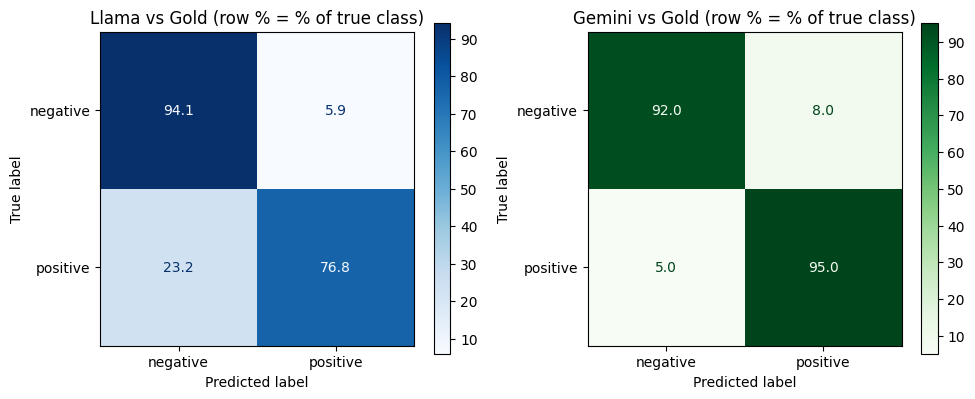

In [44]:
def plot_cm_pct(ax, y_true, y_pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, labels=labels_cls)
    cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    disp = ConfusionMatrixDisplay(cm_pct * 100, display_labels=labels_cls)
    disp.plot(ax=ax, cmap=cmap, values_format=".1f")
    ax.set_title(f"{title} (row % = % of true class)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

if llama_aligned:
    plot_cm_pct(axes[0], gold_aligned, llama_aligned, "Llama vs Gold", "Blues")
else:
    axes[0].text(0.5, 0.5, "No Llama data", ha="center", va="center", transform=axes[0].transAxes)

if llm_aligned:
    plot_cm_pct(axes[1], gold_aligned, llm_aligned, "Gemini vs Gold", "Greens")
else:
    axes[1].text(0.5, 0.5, "No LLM data", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()